# Exploratory Data Analysis (EDA)

This notebook covers the exploratory data analysis of the tabular data. For the exploratory network analysis of the graph data, see the `02_graph_eda.ipynb` notebook.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from anomaly_detector.data_commons import (
    load_figraph_columns_df,
    load_figraph_data,
    merge_df_dict,
)
from anomaly_detector.eda_utils import (
    describe_categorical,
    describe_numerical,
    draw_count_bar_plot,
    draw_stacked_count_bar_plot,
)

pd.options.display.max_colwidth = 650

/home/mario/workspace/financial_anomaly_detection/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Data

In [3]:
analyze_year_start = 2014
analyze_year_end = 2020

ANALYZE_YEARS = range(analyze_year_start, analyze_year_end + 1)

companies_dict, _ = load_figraph_data(years=ANALYZE_YEARS)
companies_df = merge_df_dict(companies_dict)

all_companies_df = merge_df_dict(load_figraph_data(years=range(2014, 2022+1))[0])

target_column = "Label"
columns_df = load_figraph_columns_df(target_column=target_column)

print(f"Train Companies Shape: {companies_df.shape}")

assert companies_df.shape[1] == columns_df.shape[0], (
    "Mismatch between data columns and feature descriptions; "
    "column metadata may not fully cover the dataset."
)

drop_columns = []
non_random_missing_columns = []

# train_companies.info()

Train Companies Shape: (23763, 775)


In [4]:
companies_df.head()

,IndustryCodeC,RegisterLongitude,RegisterLatitude,A001101000,A0d1101101,A0d1102000,A0d1102101,A0b1103000,A0b1104000,A0b1105000,...,FinLeverageRatio,CashFlowStatus,ListingAge,AssetSize,StockYield,InefficInvestDegree,InefficInvestSign,nodeID,Year,Label
0,J66,114.107633,22.540467,0.000000e+00,0.0,0.0,0.0,3.062980e+11,6.696900e+10,4.525400e+10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L000001,2014,0
1,K70,114.304642,22.597873,6.271525e+10,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,...,0.772046,0.087071,23.0,26.95,0.826145,0.010051,0.0,L000002,2014,0
2,C27,114.047458,22.551319,3.994111e+07,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,...,0.534754,-0.022854,23.0,19.64,0.336481,0.026975,1.0,L000004,2014,0
3,K70,114.119619,22.538489,5.590572e+07,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,...,0.509964,-0.007721,24.0,21.04,0.640000,0.235200,1.0,L000005,2014,0
4,K70,114.111073,22.544436,1.362612e+09,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,...,0.641420,-0.109048,22.0,23.19,0.478153,0.000843,0.0,L000006,2014,0


# Columns

In [5]:
columns_df.head()

,column,description,column_group,column_subgroup
0,IndustryCodeC,[Industry Code C] - The Industry Classification Codes of the China Securities Regulatory Commission (2012 Edition).,Other,NaN
1,RegisterLongitude,[Longitude of the Registered Address] - The longitude of the company's registered address.,Other,NaN
2,RegisterLatitude,[Latitude of the Registered Address] - The latitude of the company's registered address.,Other,NaN
3,A001101000,"[Monetary Funds] - The total amount of a company's cash on hand, bank settlement account deposits, out-of-town deposits, bank draft deposits, bank cashier's check deposits, credit card deposits, and letter of credit margin deposits. This item has been in use since 1990.",A,00
4,A0d1101101,[Among them: Customer Funds Deposits] - The amount of customer funds deposits of financial enterprises.,A,0d


In [6]:
# features_df["column"].tolist()

Tabular columns fall into **six groups by name**. Five are financial-statement item codes, where a leading letter identifies the source statement; the sixth is descriptively-named variables:
* `A<sub><id>` — Balance Sheet items (e.g. `A001000000` = Total Assets)
* `B<sub><id>` — Income Statement items (e.g. `B002000000` = Net Profit)
* `C<sub><id>` — Cash Flow Statement, direct method (e.g. `C001001000` = Cash Received from Sales)
* `D<sub><id>` — Cash Flow Statement, supplementary/indirect schedule 
* `F<id>[<letter>]` — Financial indicators / ratios
* Other — descriptive columns with full English names (e.g. `ZScore`, `EmotionTone2`)

The two characters after the statement letter form a subgroup code: `00` is the standard schedule that applies to all firms, while `0b`, `0d`, `0f`, `0i`, ... are supplementary schedules specific to banks, financial institutions, and insurers.

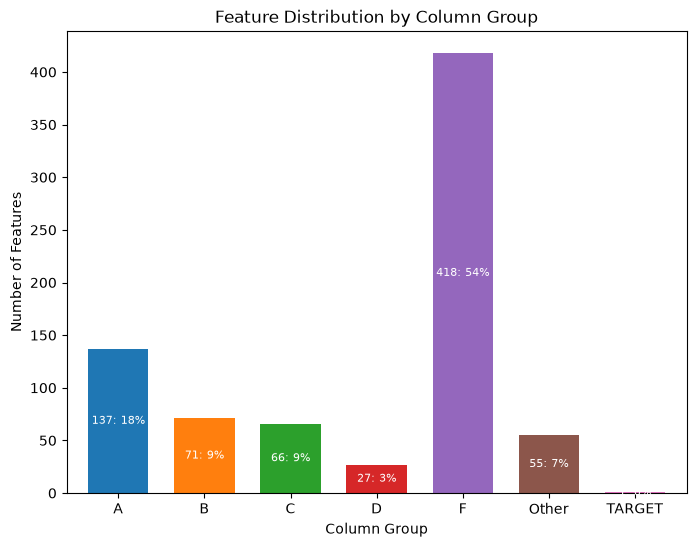

In [7]:
draw_count_bar_plot(
    columns_df["column_group"].value_counts().sort_index(),
    xlabel="Column Group",
    ylabel="Number of Features",
    title="Feature Distribution by Column Group",
)

Most of the features are financial indicators / ratios.

Because the non-`00` subgroups only exist for those specialized company types, their missingness is structural (non-random) rather than missing-at-random.

In [8]:
columns_df["column_subgroup"].dropna().unique()

array(['00', '0d', '0b', '0f', '0i', '0F', 'bd', '0I'], dtype=object)

In [9]:
non_random_missing_columns += columns_df.loc[
    lambda x: (~x["column_subgroup"].isna()) & (x["column_subgroup"] != "00"),
    "column",
].tolist()

## Setup Column Type

In [10]:
categorical_columns = [
    "nodeID",
    "Year",
    "IndustryCodeC",
    "InefficInvestSign",
    "MngmFinancialBack",
    "ConcurrentPosition",
    "ContrshrNature",
    "PropertyRightsNature",
    "IsCocurP",
    "MngmOverseaBack",
    "OneControlMany",
]

not_numerical = set([target_column] + categorical_columns)
numerical_columns = [col for col in companies_df.columns if col not in not_numerical]

# print(f"Target column: {target_column}")
# print(f"Categorical columns: {categorical_columns}")
# print(f"Numerical columns: {numerical_columns}")

# Column Validity
A change in accounting standards altered how some columns are defined - certain columns were dropped and others were added.
This section investigates those changes.

## Discontinued Features
Some of the features were discontinued even before the start period of the data collection but were kept in the dataset.

In [11]:
discontinued = columns_df["description"].str.contains(
    r"discontinued"
    r"|was cancelled after"
    r"|in use from \d{4} to \d{4}",
    regex=True,
    na=False,
)

columns_df[discontinued]

,column,description,column_group,column_subgroup
13,A001109000,"[Net Short-Term Investments] - The difference between ""Short-Term Investments"" and ""Provision for Short-Term Investment Decline in Value"". Short-term investments are various investments purchased by the company that can be readily realized and are intended to be realized at any time, including stocks and bonds held for no more than one year (inclusive), as well as other investments with a holding period of no more than one year (inclusive). This item has been in use since 1998. Although it was discontinued in 2007 under the new accounting standards, it is retained in this database.",A,00
47,A001206000,"[Net Long-Term Debt Investments] - Net long-term debt investments are the difference between long-term debt investments and the impairment provisions for long-term debt investments. These include various debt investments, such as bond investments, that the company does not plan to liquidate within one year (including one year). Although the item of long-term debt investments was cancelled after the new accounting standards in 2007, it is retained in this database.",A,00
48,A001207000,"[Net Long-Term Investments] - Net long-term investments are the difference between the total of all long-term investment items and the impairment provisions for long-term investments. Long-term investment items include long-term equity investments, long-term bond investments, and other long-term investments. This item has been in use since 1998. Although it was discontinued under the new accounting standards in 2007, it is retained in this database.",A,00
132,A003107000,"[Add: Unrecognized Investment Losses] - For long-term investment items accounted for using the equity method when preparing consolidated financial statements, when the owner's equity of the invested enterprise is negative, it represents the share of the negative owner's equity of the invested enterprise that the company undertakes. This item has been in use since 1997 and was discontinued in 2007. Losses are filled in with a ""-"" sign.",A,00
189,B001304000,"[Other Operating Profits] - Profits obtained from other sales or other business activities of the company except for the main business, after deducting other operating costs, expenses, and taxes. This item was in use from 1990 to 2007.",B,00
198,B002200000,"[Unrecognized Investment Losses] - In the case of accounting for long-term investment projects using the equity method, when preparing consolidated financial statements, if the owner's equity of the invested enterprise is negative, the share of the negative owner's equity that the company should bear. This item was in use from 1998 to 2007.",B,00


* Manually confirm the affected rows and drop them.

In [12]:
drop_columns += [
    "A001109000",
    "A001206000",
    "A001207000",
    "A003107000",
    "B001304000",
    "B002200000",
]

## Newly Introduced Features
Some feature descriptions mention "This features has been in use since ABCD", telling us when the feature first came into use. 

In [13]:
columns_df["introduced_year"] = (
    columns_df["description"]
    .str.extract(r"has been in use since\s+(\d{4})", expand=False)
    .astype("Int64")
)

features_introduced = columns_df.loc[
    lambda d: (
        ~d["column"].isin(drop_columns)
        & (d["introduced_year"] > analyze_year_start)
        & (d["introduced_year"] <= analyze_year_end)
    ),
    "column",
].tolist()

features_introduced_after_train = columns_df.loc[
    lambda d: (
        ~d["column"].isin(drop_columns) & (d["introduced_year"] > analyze_year_end)
    ),
    "column",
].tolist()

print(
    f"Features introduced after train beginning ({analyze_year_start}): {features_introduced}",
)
print(
    f"Features introduced after train end ({analyze_year_end}): {features_introduced_after_train}",
)

Features introduced after train beginning (2014): ['A001127000', 'A001128000', 'A001226000', 'A001227000', 'A001228000', 'A001229000', 'A001230000', 'A002128000', 'A002127000', 'A002211000', 'A002210000', 'A003112000', 'A003112101', 'A003112201', 'A003112301', 'A003111000', 'B001216000', 'B001211101', 'B001211203', 'B001305000', 'B001302201', 'B001306000', 'B001307000', 'B001308000', 'B001400101', 'B001500201', 'B002000301']
Features introduced after train end (2020): []


* Drop columns introduced after the training period ended, since they're unavailable for the years the model trains on.
* Columns introduced partway through the training window show non-random (structurally) missing values in the earlier years.

In [14]:
drop_columns += features_introduced
drop_columns += features_introduced_after_train

# Univariate Analysis

## Categorical Columns

In [15]:
categorical_desc = describe_categorical(companies_df, categorical_columns)
categorical_desc

,column,count,missing,missing_percentage,unique_values,mode,mode_count,mode_percentage,mode_2,mode_2_count,mode_2_percentage
0,IndustryCodeC,23752,11,0.05,81,C39,2232,9.40,C26,1585,6.67
1,PropertyRightsNature,23025,738,3.11,2,0.0,15461,67.15,1.0,7564,32.85
2,ContrshrNature,23061,702,2.95,2,0.0,20881,90.55,1.0,2180,9.45
3,ConcurrentPosition,22948,815,3.43,2,0.0,16122,70.25,1.0,6826,29.75
4,MngmFinancialBack,23689,74,0.31,2,1.0,16500,69.65,0.0,7189,30.35
5,MngmOverseaBack,23689,74,0.31,2,1.0,13941,58.85,0.0,9748,41.15
6,IsCocurP,23689,74,0.31,2,1.0,17970,75.86,0.0,5719,24.14
7,OneControlMany,23027,736,3.10,2,0.0,16413,71.28,1.0,6614,28.72
8,InefficInvestSign,19179,4584,19.29,2,0.0,11348,59.17,1.0,7831,40.83
9,nodeID,23763,0,0.00,4327,L603519,7,0.03,L603998,7,0.03


`nodeID` and `year` are identifiers rather than predictive signals, so we exclude them from the model features.

In [16]:
drop_columns += ["nodeID", "Year"]

## Numerical Columns

In [17]:
numerical_desc = describe_numerical(companies_df, numerical_columns)
numerical_desc.head()

,column,count,missing,missing_percentage,unique_values,mean,std,min,percentile_25,percentile_50,percentile_75,max,pearson_skewness,bowley_skewness,iqr_outliers_percentage
0,RegisterLongitude,23748,15,0.06,9311,1.158100e+02,6.460000e+00,76.04,1.135400e+02,1.166800e+02,1.203600e+02,1.329800e+02,-1.94,0.08,3.52
1,RegisterLatitude,23748,15,0.06,9498,3.150000e+01,6.070000e+00,18.22,2.815000e+01,3.117000e+01,3.620000e+01,4.785000e+01,0.21,0.25,0.00
2,A001101000,23635,128,0.54,23577,2.787786e+09,1.417762e+10,0.00,2.343077e+08,5.472701e+08,1.393022e+09,5.696830e+11,19.43,0.46,12.78
3,A0d1101101,5883,17880,75.24,219,1.092331e+09,8.043148e+09,0.00,0.000000e+00,0.000000e+00,0.000000e+00,1.582510e+11,10.13,NaN,3.71
4,A0d1102000,8738,15025,63.23,320,2.225130e+08,1.827882e+09,0.00,0.000000e+00,0.000000e+00,0.000000e+00,5.693400e+10,13.16,NaN,3.65


Exclude `RegisterLatitude` and `RegisterLongitude`, as they are highly identifying variables.

In [18]:
drop_columns += ["RegisterLatitude", "RegisterLongitude"]

### Verify Column Classification

The verification is done by checking the cardinality of the columns and their distributions.

In [19]:
low_cardinality = numerical_desc[
    ~numerical_desc["column"].isin(drop_columns)
    & (numerical_desc["unique_values"] < 10)
]
low_cardinality

,column,count,missing,missing_percentage,unique_values,mean,std,min,percentile_25,percentile_50,percentile_75,max,pearson_skewness,bowley_skewness,iqr_outliers_percentage
19,A0i1115000,5714,18049,75.95,7,8.557000e+02,2.917521e+04,0.000000e+00,0.0,0.0,0.0,1.408859e+06,38.03,NaN,0.11
59,A0d1218101,5713,18050,75.96,4,1.150814e+04,5.622926e+05,0.000000e+00,0.0,0.0,0.0,2.975275e+07,52.04,NaN,0.07
64,A0F1224000,5711,18052,75.97,3,8.755000e+02,4.770682e+04,0.000000e+00,0.0,0.0,0.0,3.000000e+06,56.42,NaN,0.04
70,A0d2101101,5710,18053,75.97,1,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.00,NaN,0.00
113,A0F2210000,5711,18052,75.97,3,8.821400e+02,4.798690e+04,0.000000e+00,0.0,0.0,0.0,3.000000e+06,56.17,NaN,0.04
130,A003106000,5713,18050,75.96,1,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.00,NaN,0.00
198,B002300000,5705,18058,75.99,7,7.089637e+04,5.257881e+06,-1.726205e+06,0.0,0.0,0.0,3.970780e+08,75.50,NaN,0.12
208,B006000103,3,23760,99.99,3,2.852927e+08,2.436515e+08,1.623600e+07,182418000.0,348600000.0,419821000.0,4.910420e+08,-1.09,-0.4,0.00
272,C007000000,5724,18039,75.91,3,-1.395877e+05,9.921846e+06,-7.490000e+08,0.0,0.0,0.0,0.000000e+00,-75.18,NaN,0.03
278,D000117000,5719,18044,75.93,1,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.00,NaN,0.00


Although these columns have low cardinality, they are correctly defined as numerical variables.

# Missing Values

## High Missing Percentage

In [20]:
high_missing = numerical_desc.loc[
    lambda d: ~d["column"].isin(drop_columns) & (d["missing_percentage"] > 99)
].sort_values("missing_percentage", ascending=False)
high_missing

,column,count,missing,missing_percentage,unique_values,mean,std,min,percentile_25,percentile_50,percentile_75,max,pearson_skewness,bowley_skewness,iqr_outliers_percentage
208,B006000103,3,23760,99.99,3,2.852927e+08,2.436515e+08,16236000.0,182418000.0,348600000.0,419821000.0,491042000.0,-1.09,-0.4,0.0


Drop the columns with a very high missing rate.

In [21]:
drop_columns += high_missing["column"].tolist()

## Co-Missing Columns

In [22]:
def group_co_missing_cols(corr, threshold):
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = upper.stack().loc[lambda s: s >= threshold].index

    parent = {col: col for pair in pairs for col in pair}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    for a, b in pairs:
        parent[find(a)] = find(b)

    groups = defaultdict(set)
    for col in parent:
        groups[find(col)].add(col)

    return sorted((sorted(g) for g in groups.values()), key=len, reverse=True)


missing_corrs = (
    companies_df[columns_df.loc[lambda x: x["column_group"] != "F", "column"].tolist()]
    .isna()
    .corr()
)
co_missing_sets = group_co_missing_cols(missing_corrs, threshold=0.999)
for co_missing_set in co_missing_sets:
    print(co_missing_set)

['A0i1116101', 'A0i1116201', 'A0i1116301', 'A0i1116401', 'A0i1209000', 'A0i1225000', 'A0i2116000', 'A0i2118000', 'A0i2119101', 'A0i2119201', 'A0i2119301', 'A0i2119401', 'A0i2124000']
['A001109000', 'A001206000', 'A001207000', 'A003106000', 'A003107000', 'A0F1224000', 'A0F2210000', 'A0d1218101', 'A0d2101101', 'A0i1115000']
['AddInvestExpend', 'AssetSize', 'CashFlowStatus', 'FinLeverageRatio', 'InefficInvestDegree', 'InefficInvestSign', 'ListingAge', 'MaintainInvest', 'StockYield', 'TotalInvest']
['B0i1103203', 'B0i1103303', 'B0i1203101', 'B0i1203203', 'B0i1204101', 'B0i1204203', 'B0i1208103']
['ActualDebtRatio', 'ExcessiveDebtDegree', 'FixedAssetsProp', 'Growth', 'IndLeverageRatioMedian', 'Profitability', 'TargetDebtRatio']
['AverageAge', 'IsCocurP', 'MaleRatio', 'MngmFinancialBack', 'MngmOverseaBack']
['A001100000', 'A001200000', 'A002100000']
['B0d1104101', 'B0d1104201', 'B0d1104301']
['Boardsize', 'ExecutivesNumber', 'SupervisorSize']
['RegisterLatitude', 'RegisterLongitude']
['A0d11

Features from the same subgroup go missing together. This is expected, since these features only apply to specific types of companies.

## Missigness of Changed Columns

In [23]:
(
    numerical_desc.loc[
        lambda d: (
            ~d["column"].isin(drop_columns) & d["column"].isin(features_introduced)
        )
    ]
    .merge(columns_df[["column", "introduced_year"]], on="column", how="inner")
    .sort_values("introduced_year")
)

,column,count,missing,missing_percentage,unique_values,mean,std,min,percentile_25,percentile_50,percentile_75,max,pearson_skewness,bowley_skewness,iqr_outliers_percentage,introduced_year


These columns have non-random misigness.

# Companies
## Unique Companies

In [24]:
print(
    f"There are {len(companies_df['nodeID'].unique())}"
    " unique companies in the training set.",
)

There are 4327 unique companies in the training set.


## New Companies In Year

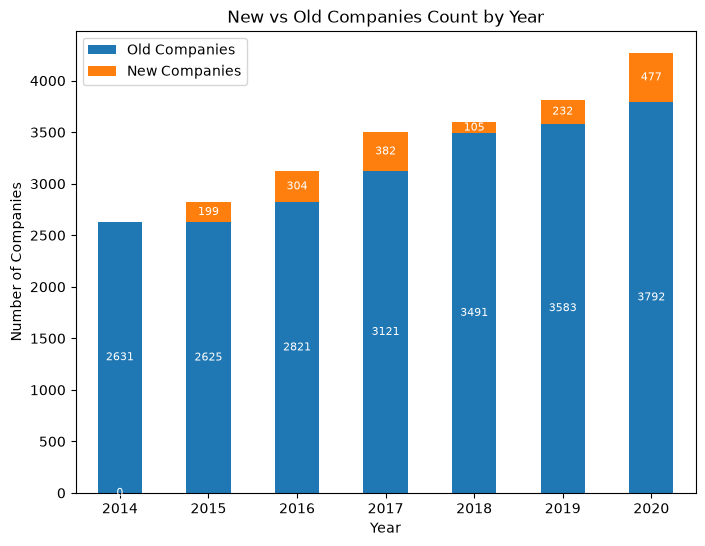

In [25]:
companies_in_year = {}

for year in companies_df["Year"].unique():
    companies_in_year[int(year)] = set(
        companies_df[companies_df["Year"] == year]["nodeID"].unique().tolist(),
    )

new_companies_count = {}
for year in sorted(companies_in_year.keys()):
    if year == min(companies_in_year.keys()):
        new_companies_count[year] = 0
    else:
        new_companies_count[year] = len(
            companies_in_year[year] - companies_in_year[year - 1],
        )

companies_year_count = (
    companies_df.groupby("Year")["nodeID"].count().to_frame(name="companies_count")
)
companies_year_count["New Companies"] = new_companies_count
companies_year_count["Old Companies"] = (
    companies_year_count["companies_count"] - companies_year_count["New Companies"]
)

draw_stacked_count_bar_plot(
    companies_year_count[["Old Companies", "New Companies"]],
    title="New vs Old Companies Count by Year",
    xlabel="Year",
    ylabel="Number of Companies",
    label="count",
)

The number of companies present each year is steadily increasing.

# Company Coordinates

In [26]:
# Check if there are multiple companies on the same coordinates
companies_df[["RegisterLatitude", "RegisterLongitude", "nodeID"]].groupby(
    ["RegisterLatitude", "RegisterLongitude"],
).agg({"nodeID": "count"}).sort_values(by="nodeID", ascending=False).describe()

,nodeID
count,9525.000000
mean,2.493228
std,1.569034
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,20.000000


Some coordinates have multiple companies registered at them.

# Target Column

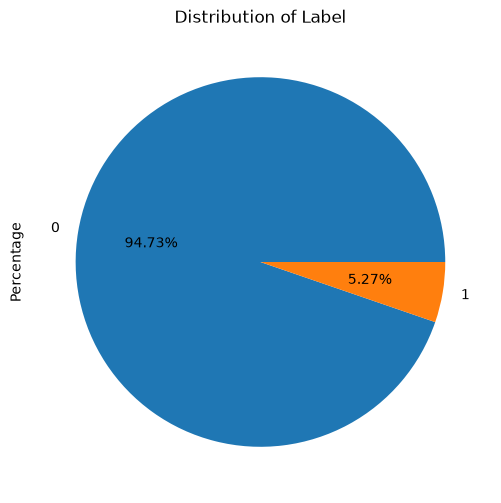

In [27]:
_, ax = plt.subplots(figsize=(8, 6))
companies_df[target_column].value_counts(normalize=True, dropna=False).plot.pie(
    autopct="%1.2f%%",
    ylabel="Percentage",
    ax=ax,
)
plt.title(f"Distribution of {target_column}")
plt.show()

The dataset suffers from strong class imbalance, with only 5.3% positive labels.

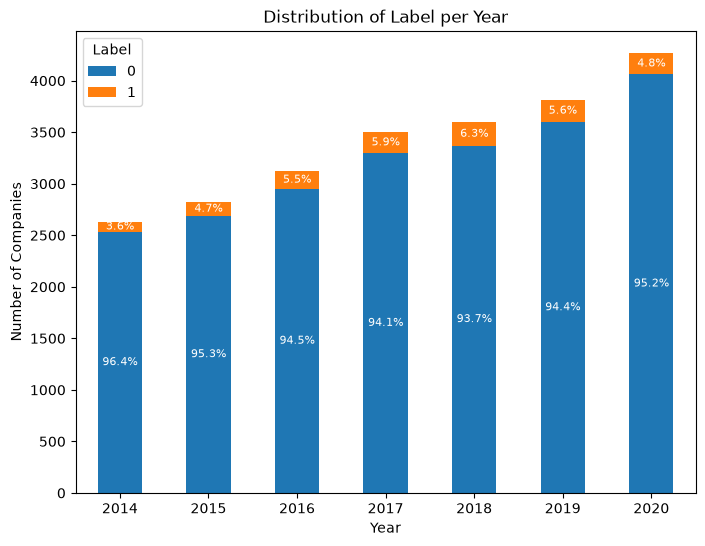

In [28]:
label_by_year = pd.crosstab(companies_df["Year"], companies_df[target_column])

draw_stacked_count_bar_plot(
    label_by_year,
    title=f"Distribution of {target_column} per Year",
    xlabel="Year",
    ylabel="Number of Companies",
    label="percentage",
)

### Class Imbalance Accross All Years
Includes all years from 2014 to 2022, not just the training years.

In [31]:
class_imbalance_df = pd.crosstab(all_companies_df["Year"], all_companies_df[target_column])
class_imbalance_df["count"] = class_imbalance_df[0] + class_imbalance_df[1]
class_imbalance_df["pos_rate"] = class_imbalance_df[1] / class_imbalance_df["count"] * 100

class_imbalance_df

Label,0,1,count,pos_rate
Year,,,,
2014,2536,95,2631,3.610794
2015,2690,134,2824,4.745042
2016,2952,173,3125,5.536000
2017,3298,205,3503,5.852127
2018,3371,225,3596,6.256952
2019,3601,214,3815,5.609436
2020,4062,207,4269,4.848911
2021,4586,183,4769,3.837282
2022,5009,123,5132,2.396726


The rate peaks in 2018 and then falls, so the test years (2021-2022) have the fewest positives.

## Per Company Label Distribution

In [64]:
company_fraud_counts = companies_df.groupby("nodeID").agg(
    years_present=("Label", "count"),
    years_fraud=("Label", "sum"),
    at_least_one_fraud=("Label", "max"),
)
company_fraud_counts.head(2)

,years_present,years_fraud,at_least_one_fraud
nodeID,,,
L000001,7,0,0
L000002,7,0,0


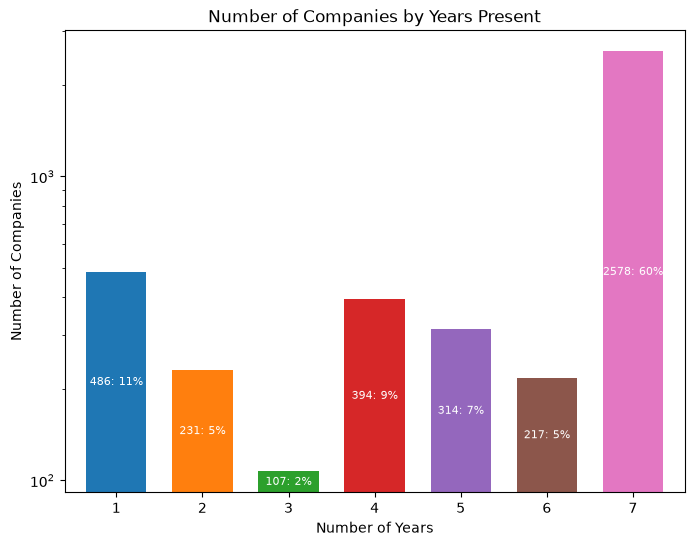

In [65]:
counts = company_fraud_counts["years_present"].value_counts().sort_index()

draw_count_bar_plot(
    counts,
    title="Number of Companies by Years Present",
    xlabel="Number of Years",
    ylabel="Number of Companies",
    scale="log",
)

Most companies (60%) are present in the dataset for the entire training period, while some appear for only a few years.

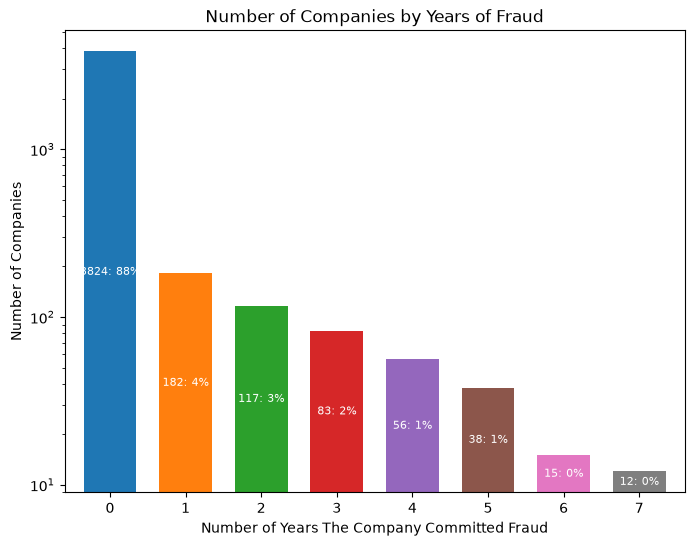

In [66]:
counts = company_fraud_counts["years_fraud"].value_counts().sort_index()

draw_count_bar_plot(
    counts,
    title="Number of Companies by Years of Fraud",
    xlabel="Number of Years The Company Committed Fraud",
    ylabel="Number of Companies",
    scale="log",
)

Most companies never committed fraud, and the number of companies decreases as the number of fraudulent years increases.

# Tabular EDA Conclusion
## Columns to be Dropped

In [67]:
print(drop_columns)

['A001109000', 'A001206000', 'A001207000', 'A003107000', 'B001304000', 'B002200000', 'A001127000', 'A001128000', 'A001226000', 'A001227000', 'A001228000', 'A001229000', 'A001230000', 'A002128000', 'A002127000', 'A002211000', 'A002210000', 'A003112000', 'A003112101', 'A003112201', 'A003112301', 'A003111000', 'B001216000', 'B001211101', 'B001211203', 'B001305000', 'B001302201', 'B001306000', 'B001307000', 'B001308000', 'B001400101', 'B001500201', 'B002000301', 'nodeID', 'Year', 'RegisterLatitude', 'RegisterLongitude', 'B006000103']


## Columns with Non-Random Missingness
The missingness in these features is not random, so special attention should be given to these columns during preprocessing.

In [68]:
print([col for col in non_random_missing_columns if col not in drop_columns])

['A0d1101101', 'A0d1102000', 'A0d1102101', 'A0b1103000', 'A0b1104000', 'A0b1105000', 'A0f1106000', 'A0f1108000', 'A0i1113000', 'A0i1114000', 'A0i1115000', 'A0i1116000', 'A0i1116101', 'A0i1116201', 'A0i1116301', 'A0i1116401', 'A0f1122000', 'A0d1126000', 'A0i1224000', 'A0i1225000', 'A0b1201000', 'A0i1209000', 'A0i1210000', 'A0d1218101', 'A0F1224000', 'A0f1300000', 'A0d2101101', 'A0b2102000', 'A0b2103000', 'A0b2103101', 'A0b2103201', 'A0f2104000', 'A0f2106000', 'A0f2110000', 'A0i2111000', 'A0i2116000', 'A0i2117000', 'A0i2118000', 'A0i2119000', 'A0i2119101', 'A0i2119201', 'A0i2119301', 'A0i2119401', 'A0i2121000', 'A0d2122000', 'A0d2123000', 'A0i2124000', 'A0d2202000', 'A0F2210000', 'A0f2300000', 'A0f3104000', 'A0F3108000', 'A0F3109000', 'Bbd1102000', 'Bbd1102101', 'Bbd1102203', 'B0i1103000', 'B0i1103101', 'B0i1103111', 'B0i1103203', 'B0i1103303', 'B0d1104000', 'B0d1104101', 'B0d1104201', 'B0d1104301', 'B0d1104401', 'B0d1104501', 'B0f1105000', 'B0i1202000', 'B0i1203000', 'B0i1203101', 'B0i1